In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F


In [3]:
import os


pretrained_models = os.listdir('./logs/siren/s3_256/checkpoints/')
pth_files = [f for f in pretrained_models if f.endswith('.pth')]
pth_list = sorted(pth_files)

In [4]:
mdl_dir = './logs/siren/s3_256/checkpoints/'
from src.siren import SirenModel

state_dict = torch.load(mdl_dir + pth_list[0], weights_only=True)
# strip _orig_mod. prefix added by torch.compile
state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}

model = SirenModel(in_features=3, out_features=1, hidden_features=256, hidden_layers=3)
model.load_state_dict(state_dict)


<All keys matched successfully>

In [5]:
import numpy as np
import tifffile

input_path = '10-2900-control-cell-05.oif-C0.v3dpbd.tif'
volume = tifffile.imread(input_path)
volume_shape = volume.shape  # (D, H, W)

axes = [np.linspace(-1, 1, s, dtype=np.float32) for s in volume_shape]
coords = np.stack([g.flatten() for g in np.meshgrid(*axes, indexing='ij')], axis=-1)
coords_t = torch.from_numpy(coords)

batch_size = 2**20
preds = []
model.cuda()
with torch.no_grad():
    for i in range(0, len(coords_t), batch_size):
        out = model(coords_t[i:i+batch_size].cuda())
        preds.append(out.squeeze(-1).cpu())

reconstructed = torch.cat(preds).numpy().reshape(volume_shape)
reconstructed

array([[[0.06371264, 0.06395541, 0.06403731, ..., 0.06307492,
         0.06366257, 0.06423543],
        [0.06352405, 0.06377715, 0.06386314, ..., 0.06304298,
         0.06370893, 0.06434734],
        [0.06325439, 0.06349403, 0.06356916, ..., 0.06298062,
         0.06372119, 0.06441882],
        ...,
        [0.06248251, 0.06130217, 0.06007719, ..., 0.05943719,
         0.06010705, 0.0612307 ],
        [0.06296191, 0.06179969, 0.06058589, ..., 0.06008458,
         0.0607101 , 0.06177421],
        [0.06352508, 0.06240591, 0.06123048, ..., 0.06101297,
         0.06151353, 0.06239922]],

       [[0.06446354, 0.06442788, 0.06423193, ..., 0.05931382,
         0.05976309, 0.06027913],
        [0.06436636, 0.06434427, 0.06414343, ..., 0.05973674,
         0.0601642 , 0.06063578],
        [0.06424589, 0.06421998, 0.06399468, ..., 0.06018484,
         0.06060764, 0.06105281],
        ...,
        [0.0645947 , 0.06400898, 0.06330626, ..., 0.0603998 ,
         0.06104341, 0.06186482],
        [0.0

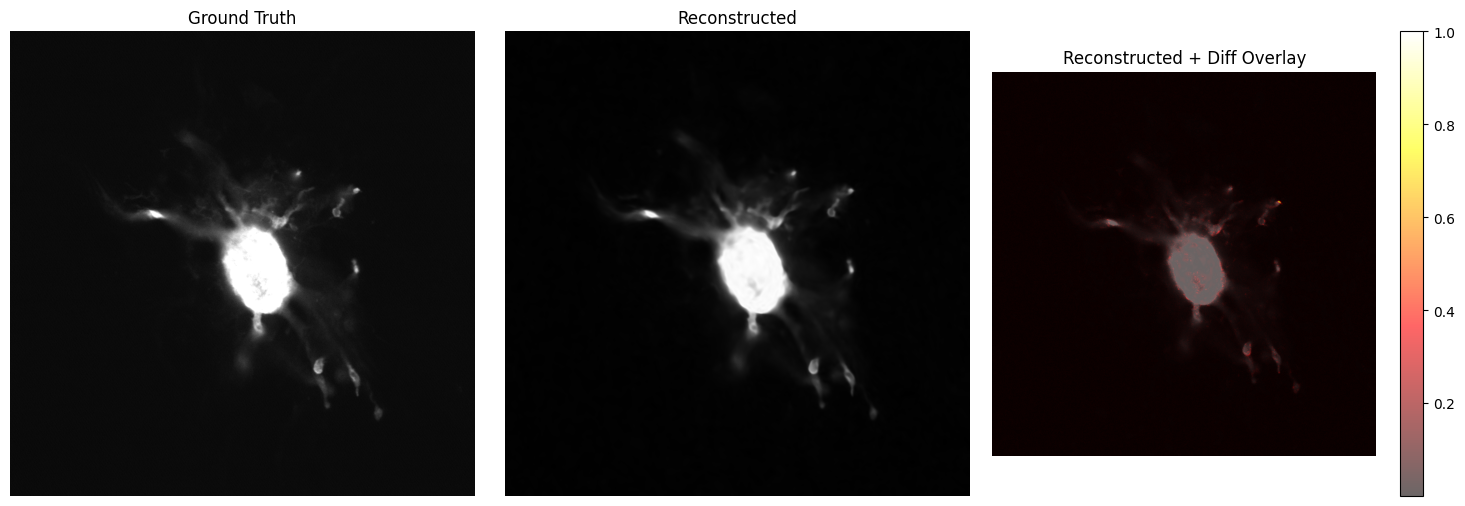

PSNR: 40.20 dB


In [6]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

gt = volume.astype(np.float32)
gt = (gt - gt.min()) / (gt.max() - gt.min())

z = volume_shape[0] // 2  # mid-slice along depth axis
diff = np.abs(reconstructed - gt)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gt[z], cmap='gray');            axes[0].set_title('Ground Truth');  axes[0].axis('off')
axes[1].imshow(reconstructed[z], cmap='gray'); axes[1].set_title('Reconstructed'); axes[1].axis('off')

# overlay diff (hot colormap) on reconstructed with alpha
axes[2].imshow(reconstructed[z], cmap='gray')
diff_norm = diff[z] / (diff[z].max() + 1e-8)
overlay = axes[2].imshow(diff_norm, cmap='hot', alpha=0.6)
plt.colorbar(overlay, ax=axes[2])
axes[2].set_title('Reconstructed + Diff Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()

psnr = -10 * np.log10(((reconstructed - gt) ** 2).mean() + 1e-8)
print(f'PSNR: {psnr:.2f} dB')

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/lpips/weights/v0.1/alex.pth


/home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, ma

Whole-volume  PSNR=40.20dB  SSIM=0.9319  LPIPS=0.2829
  Slice  20   PSNR=41.37dB  SSIM=0.9303  LPIPS=0.2872
  Slice  40   PSNR=39.63dB  SSIM=0.9309  LPIPS=0.2800
  Slice  60   PSNR=39.77dB  SSIM=0.9311  LPIPS=0.2883
  Slice  80   PSNR=38.69dB  SSIM=0.9292  LPIPS=0.2743


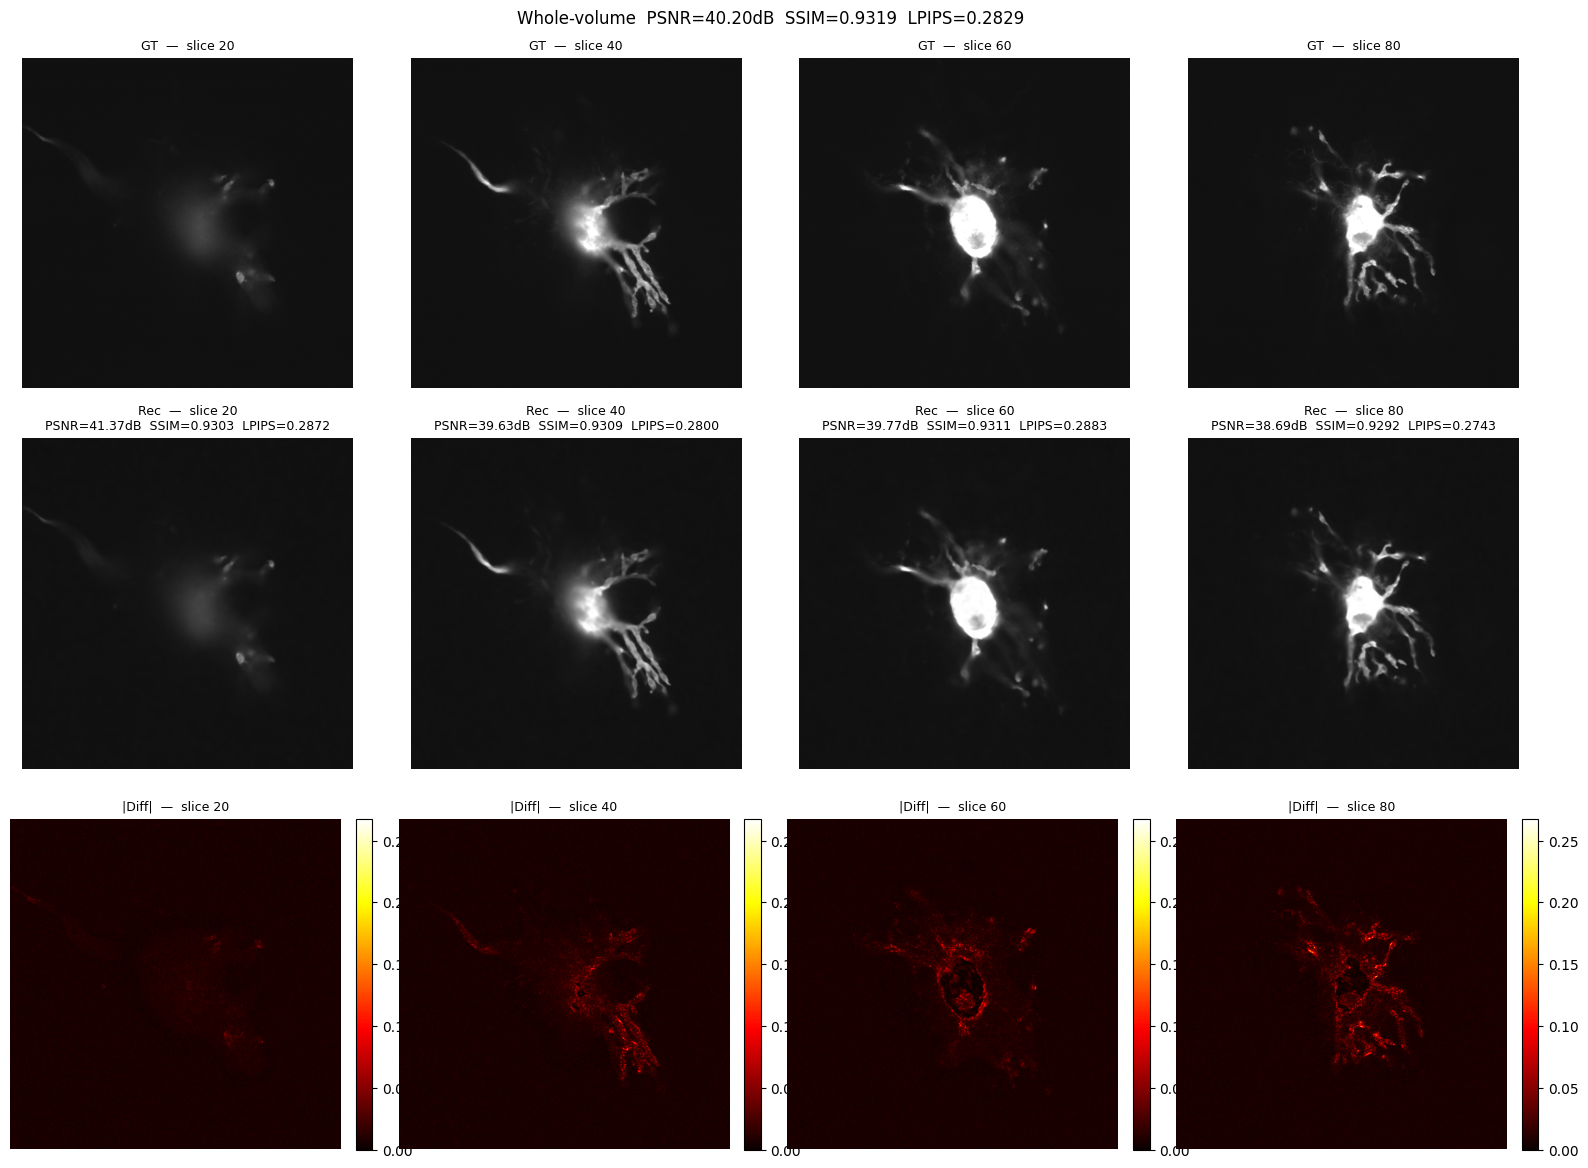

In [7]:

import lpips
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from skimage.metrics import structural_similarity as ssim_fn

SLICE_INDICES = [20, 40, 60, 80]

def psnr(a, b):
    return -10 * np.log10(((a - b) ** 2).mean() + 1e-8)

# ── LPIPS setup ───────────────────────────────────────────────────────────────
loss_fn_lpips = lpips.LPIPS(net='alex').cuda()
loss_fn_lpips.eval()

def to_lpips(arr2d):
    t = torch.from_numpy(arr2d).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)
    return (t * 2 - 1).cuda()

# ── per-slice metrics ─────────────────────────────────────────────────────────
slice_ssim, slice_lpips_vals, slice_psnr = [], [], []

for z in SLICE_INDICES:
    gt_s, rec_s = gt[z], reconstructed[z]
    slice_ssim.append(ssim_fn(gt_s, rec_s, data_range=1.0))
    slice_psnr.append(psnr(gt_s, rec_s))
    with torch.no_grad():
        slice_lpips_vals.append(loss_fn_lpips(to_lpips(gt_s), to_lpips(rec_s)).item())

# ── whole-volume metrics ──────────────────────────────────────────────────────
vol_ssim  = ssim_fn(gt, reconstructed, data_range=1.0)
vol_psnr  = psnr(gt, reconstructed)

with torch.no_grad():
    gt_batch  = torch.stack([to_lpips(gt[z]).squeeze(0)  for z in range(gt.shape[0])])
    rec_batch = torch.stack([to_lpips(reconstructed[z]).squeeze(0) for z in range(gt.shape[0])])
    chunk = 16
    lp_all = []
    for i in range(0, gt_batch.shape[0], chunk):
        lp_all.append(loss_fn_lpips(gt_batch[i:i+chunk], rec_batch[i:i+chunk]).squeeze().cpu().numpy())
    vol_lpips = float(np.concatenate([np.atleast_1d(x) for x in lp_all]).mean())

print(f"Whole-volume  PSNR={vol_psnr:.2f}dB  SSIM={vol_ssim:.4f}  LPIPS={vol_lpips:.4f}")
for z, s, l, p in zip(SLICE_INDICES, slice_ssim, slice_lpips_vals, slice_psnr):
    print(f"  Slice {z:3d}   PSNR={p:.2f}dB  SSIM={s:.4f}  LPIPS={l:.4f}")

# ── figure ────────────────────────────────────────────────────────────────────
n = len(SLICE_INDICES)
fig = plt.figure(figsize=(n * 4, 12))
gs = gridspec.GridSpec(3, n, figure=fig, hspace=0.15, wspace=0.05,
                       top=0.93, bottom=0.02, left=0.02, right=0.98)

diff_max = max(np.abs(reconstructed[z] - gt[z]).max() for z in SLICE_INDICES)

for col, (z, s, l, p) in enumerate(zip(SLICE_INDICES, slice_ssim, slice_lpips_vals, slice_psnr)):
    diff = np.abs(reconstructed[z] - gt[z])

    ax_gt = fig.add_subplot(gs[0, col])
    ax_gt.imshow(gt[z], cmap='gray', vmin=0, vmax=1)
    ax_gt.set_title(f'GT  —  slice {z}', fontsize=9)
    ax_gt.axis('off')

    ax_rec = fig.add_subplot(gs[1, col])
    ax_rec.imshow(reconstructed[z], cmap='gray', vmin=0, vmax=1)
    ax_rec.set_title(f'Rec  —  slice {z}\nPSNR={p:.2f}dB  SSIM={s:.4f}  LPIPS={l:.4f}', fontsize=9)
    ax_rec.axis('off')

    ax_diff = fig.add_subplot(gs[2, col])
    im = ax_diff.imshow(diff, cmap='hot', vmin=0, vmax=diff_max)
    ax_diff.set_title(f'|Diff|  —  slice {z}', fontsize=9)
    ax_diff.axis('off')
    plt.colorbar(im, ax=ax_diff, fraction=0.046, pad=0.04)

os.makedirs('experiments/siren/s3_256', exist_ok=True)
fig.suptitle(
    f'Whole-volume  PSNR={vol_psnr:.2f}dB  SSIM={vol_ssim:.4f}  LPIPS={vol_lpips:.4f}',
    fontsize=12, y=0.97
)
plt.savefig('experiments/siren/s3_256/comparison_slices.pdf', dpi=500, bbox_inches='tight')
plt.show()


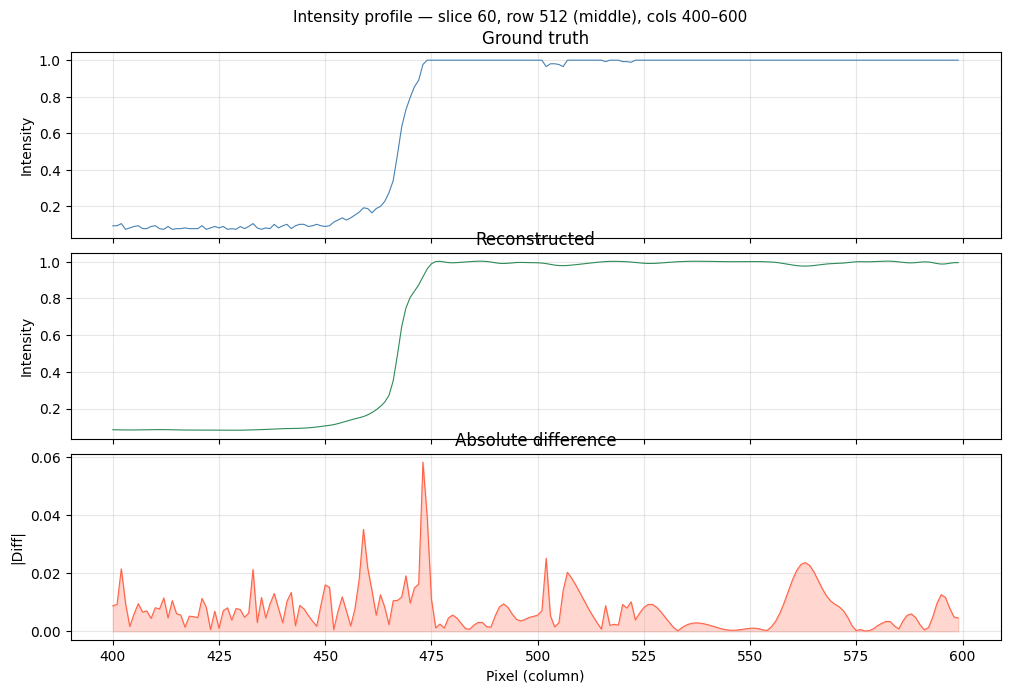

In [14]:
# ── intensity profile: slice 40, middle row, columns 400-600 ─────────────────
z_idx    = 60
row      = gt.shape[1] // 2   # middle row
col_lo, col_hi = 400, 600

gt_row  = gt[z_idx, row, col_lo:col_hi]
rec_row = reconstructed[z_idx, row, col_lo:col_hi]
dif_row = np.abs(gt_row - rec_row)
x_px    = np.arange(col_lo, col_hi)

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
fig.subplots_adjust(hspace=0.08, top=0.92, bottom=0.08)

axes[0].plot(x_px, gt_row,  color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Intensity'); axes[0].set_title('Ground truth')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_px, rec_row, color='seagreen',  linewidth=0.8)
axes[1].set_ylabel('Intensity'); axes[1].set_title('Reconstructed')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x_px, dif_row, color='tomato',    linewidth=0.8)
axes[2].fill_between(x_px, dif_row, alpha=0.25, color='tomato')
axes[2].set_ylabel('|Diff|'); axes[2].set_title('Absolute difference')
axes[2].set_xlabel('Pixel (column)')
axes[2].grid(True, alpha=0.3)

fig.suptitle(
    f'Intensity profile — slice {z_idx}, row {row} (middle), cols {col_lo}–{col_hi}',
    fontsize=11
)
os.makedirs('experiments/siren/s3_256', exist_ok=True)
plt.savefig('experiments/siren/s3_256/intensity_profile.pdf', bbox_inches='tight')
plt.show()


In [13]:
slice_max = gt.max(axis=(1, 2))
top5 = np.argsort(slice_max)[-5:][::-1]
for i in top5:
    print(f"slice {i:3d}  max={slice_max[i]:.4f}  mean={gt[i].mean():.4f}")
print(f"\nslice 40  max={gt[40].max():.4f}  mean={gt[40].mean():.4f}")


slice  56  max=1.0000  mean=0.1004
slice  55  max=1.0000  mean=0.1006
slice  58  max=1.0000  mean=0.1008
slice  59  max=1.0000  mean=0.1006
slice  60  max=1.0000  mean=0.1008

slice 40  max=1.0000  mean=0.0956


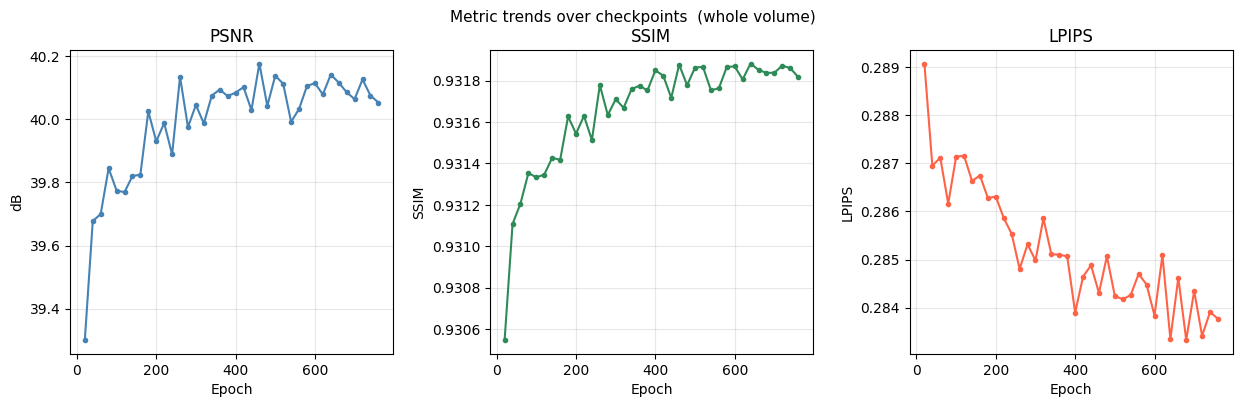

In [10]:
import re
from torchmetrics.functional.image import structural_similarity_index_measure as ssim_gpu

# ── filter & sort epoch checkpoints ──────────────────────────────────────────
epoch_ckpts = sorted(
    [f for f in pth_list if re.search(r'_epoch_\d+\.pth$', f)],
    key=lambda f: int(re.search(r'_epoch_(\d+)\.pth$', f).group(1))
)
epochs_x = [int(re.search(r'_epoch_(\d+)\.pth$', f).group(1)) for f in epoch_ckpts]

if not epoch_ckpts:
    raise RuntimeError('No epoch checkpoints found.')

D, H, W  = volume_shape
infer_chunk = 2**20
# 16 uniformly spaced depth slices for LPIPS — enough for a trend line
lpips_idx = list(range(0, D, max(1, D // 16)))[:16]

# ── move constants to GPU once ────────────────────────────────────────────────
coords_cuda    = coords_t.cuda()
gt_gpu         = torch.from_numpy(gt).cuda()                             # (D,H,W)
gt_lpips_batch = (torch.from_numpy(gt[lpips_idx])
                  .unsqueeze(1).repeat(1, 3, 1, 1) * 2 - 1).cuda()      # (16,3,H,W)

# ── metric loop ───────────────────────────────────────────────────────────────
trend_psnr, trend_ssim, trend_lpips = [], [], []

for ckpt_name in epoch_ckpts:
    sd = torch.load(mdl_dir + ckpt_name, weights_only=True)
    sd = {k.replace('_orig_mod.', ''): v for k, v in sd.items()}
    model.load_state_dict(sd)
    model.cuda().eval()

    # inference — full volume, AMP
    preds = []
    with torch.no_grad(), torch.amp.autocast('cuda'):
        for i in range(0, len(coords_cuda), infer_chunk):
            preds.append(model(coords_cuda[i:i+infer_chunk]).squeeze(-1))
    rec_gpu = torch.cat(preds).reshape(D, H, W).float()  # (D,H,W) on GPU

    # PSNR — GPU
    mse = ((rec_gpu - gt_gpu) ** 2).mean().item()
    trend_psnr.append(-10 * np.log10(mse + 1e-8))

    # SSIM — GPU via torchmetrics (treats depth slices as batch)
    ssim_val = ssim_gpu(
        rec_gpu.unsqueeze(1),   # (D,1,H,W)
        gt_gpu.unsqueeze(1),
        data_range=1.0
    ).item()
    trend_ssim.append(ssim_val)

    # LPIPS — 16 slices, single batch on GPU
    rec_lpips_batch = (rec_gpu[lpips_idx]
                       .unsqueeze(1).repeat(1, 3, 1, 1) * 2 - 1)        # (16,3,H,W)
    with torch.no_grad():
        lp = loss_fn_lpips(gt_lpips_batch, rec_lpips_batch).mean().item()
    trend_lpips.append(lp)

    del rec_gpu, rec_lpips_batch
    torch.cuda.empty_cache()

# restore model to original checkpoint
sd = torch.load(mdl_dir + pth_list[0], weights_only=True)
sd = {k.replace('_orig_mod.', ''): v for k, v in sd.items()}
model.load_state_dict(sd)
model.cuda().eval()

# ── trend plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.subplots_adjust(wspace=0.3, top=0.88, bottom=0.12)

kw = dict(marker='o', markersize=3, linewidth=1.5)

axes[0].plot(epochs_x, trend_psnr,  color='steelblue', **kw)
axes[0].set_title('PSNR'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('dB')
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_x, trend_ssim,  color='seagreen', **kw)
axes[1].set_title('SSIM'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('SSIM')
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_x, trend_lpips, color='tomato', **kw)
axes[2].set_title('LPIPS'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LPIPS')
axes[2].grid(True, alpha=0.3)

fig.suptitle('Metric trends over checkpoints  (whole volume)', fontsize=11)
os.makedirs('experiments/siren/s3_256', exist_ok=True)
plt.savefig('experiments/siren/s3_256/metric_trends.pdf', bbox_inches='tight')
plt.show()
